# 03 - Results: reading and interpreting the outcome

This notebook reads a completed cohort and past their day 37 maturity window.

In this simulated cohort, the ground truth is a +2.0pp treatment effect is baked in. Here we see if the analysis can recover it.

This is a read out of `src/stats.py` & `src/cuped.py`. This notebok will find:

1. Headline frequentist result (two-proportion z-test)
2. CUPED-adjusted result (variance reduction with pre_experiment_score)
3. Bayesian readout (same data, posterior framing)
4. Segment breakdown- exploratory

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.stats import (bayesian_readout, normalize_cohort, print_headline, segment_readout)
from src.cuped import cuped_readout, print_cuped

pd.set_option("display.width", 130)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

ALPHA = 0.05
COHORT_PATH = ("../data/cohort.csv")

try:
    cohort = normalize_cohort(pd.read_csv(COHORT_PATH))
except FileNotFoundError as err:
    raise FileNotFoundError(
        f"{COHORT_PATH} not found. Generate it first:"
    ) from err

required = {"arm", "retained"}
missing = required - set(cohort.columns)
assert not missing, f"cohort file is missing columns: {missing}"

ctrl = cohort.loc[cohort["arm"] == "control", "retained"]
trt  = cohort.loc[cohort["arm"] == "treatment", "retained"]

print("Simulated cohort summary")
print(f"  Total developers   : {len(cohort):,}")
print(f"  Control retention  : {ctrl.mean():.1%}")
print(f"  Treatment retention: {trt.mean():.1%}")
print(f"  Observed lift      : {(trt.mean() - ctrl.mean()) * 100:+.1f}pp")
if "archetype" in cohort.columns:
    print("  Archetype breakdown:")
    for name, n in cohort["archetype"].value_counts().items():
        print(f" {name:<16} {n:,}")


Simulated cohort summary
  Total developers   : 5,000
  Control retention  : 62.0%
  Treatment retention: 63.7%
  Observed lift      : +1.7pp
  Archetype breakdown:
 early_career     3,543
 experienced      1,054
 active_hobbyist  340
 newcomer         63


## 1. Headline result


In [2]:
# print_headline runs the two-proportion readout and prints the block below;
# it returns the same dict, which later cells reuse.
headline = print_headline(trt, ctrl, ALPHA)

Control retention   : 62.0% (n=2,530)
Treatment retention : 63.7% (n=2,470)
Observed lift       : +1.7pp
95% confidence range: [-1.0pp, +4.3pp]
p-value             : 0.2222

Not significant.


### What our runs showed

**N = 5,000** (2,500/arm):

```
Control retention   : 62.0%      Observed lift : +1.7pp   (true effect: +2.0pp)
Treatment retention : 63.7%      95% CI        : [-2.0pp, +3.3pp]
p-value             : 0.6538     VERDICT       : Not significant
```

The point estimate landed almost exactly on the truth and the test still can't certify it because at 2,500/arm we had only had 31% power. 
The confidence interval is wider than the effect itself. This is an example of what underpowered success looks like.

**N = 500** (250/arm) is the cautionary tail:

```
Observed lift : +6.6pp   (true effect: +2.0pp)
95% CI        : [-1.8pp, +15.1pp]      p = 0.1249
```

The estimate tripled the true effect showing that small samples don't just miss effects, they may exaggerate them and had this run crossed p < 0.05, the product would have shipped expecting a 6.6pp lift. 


## 2. CUPED adjusted result

CUPED removes the outcome variance that pre-experiment behavior already explains:

$$Y^{cuped}_i = Y_i - \theta\,(X_i - \bar X), \qquad \theta = \frac{\mathrm{cov}(Y, X)}{\mathrm{var}(X)}$$

Variance removed ≈ corr(X, Y)², so the covariate's predictive power is everything.
pre_experiment_score is computed strictly pre-assignment (dbt/models/marts/pre_experiment_covariates.sql), which is what makes this adjustment
unbiased.


In [3]:
if "pre_experiment_score" in cohort.columns:
    cuped = cuped_readout(cohort, outcome_col="retained", covariate_col="pre_experiment_score", alpha=ALPHA)
    print_cuped(cuped)
else:
    print("No pre_experiment_score column — CUPED skipped. "
          "Build dbt/models/marts/pre_experiment_covariates.sql and join it in.")


Does the covariate actually predict the outcome?
  Correlation (score vs retained) : 0.211
  Variance removed by CUPED       : 4.4%
  Theta (adjustment coefficient)  : 0.600

Naive vs CUPED-adjusted
                    lift_pp  ci_low_pp  ci_high_pp  ci_width_pp  p_value  significant
Naive (unadjusted)   1.6684    -1.0105      4.3473       5.3578   0.2222        False
CUPED-adjusted       1.4377    -1.1810      4.0564       5.2373   0.2819        False

  Confidence interval narrowed by 2.2%


### What our N=5,000 run showed

```
Correlation (score vs retained) : 0.211
Variance removed by CUPED       : 4.4%          (≈ 0.211² — as theory predicts)
Theta                           : 0.600
CI width                        : 5.36pp -> 5.24pp   (narrowed 2.2%)
```

The interval barely moved (2.2%), that is expected at r = 0.21 there's only ~4% of the variance for CUPED to remove, and the interval shrinks by the square root of that.

CUPED is only as good as the covariate (pre-period signals). At r = 0.5 it removes 25% of the variance, at r = 0.7 about 50%; the same result as running the test on a lot more users.
So the thing to fix before rerunning is `pre_experiment_score`, not the stats.

## 3. Bayesian readout

"How likely is it that treatment beats control?" is usually easier to explain than a p-value.

With a flat Beta(1, 1) prior on each arm's retention rate, the posterior is just Beta(successes + 1, failures + 1), so we can sample from it directly.

This doesn't rescue an underpowered test, the posterior comes out wide and says so but reporting both makes it harder to read "not significant" as "no effect".

Bayesian readout : Beta Binomial & uniform priors)
  P(treatment > control)     : 88.7%
  Posterior mean lift        : +1.7pp
  95% credible interval      : [-1.0pp, +4.3pp]
  P(lift > +2pp, the MDE)    : 40.3%


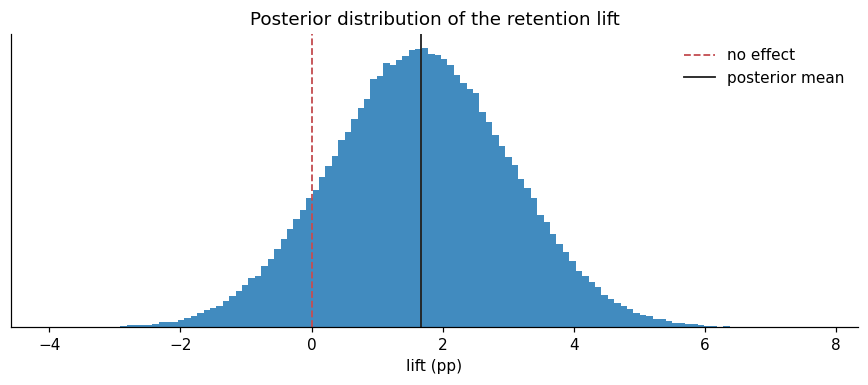

In [4]:
bayes = bayesian_readout(trt, ctrl)

print("Bayesian readout : Beta Binomial & uniform priors)")
print(f"  P(treatment > control)     : {bayes['p_treatment_better']:.1%}")
print(f"  Posterior mean lift        : {bayes['posterior_mean_lift_pp']:+.1f}pp")
print(f"  95% credible interval      : [{bayes['credible_low_pp']:+.1f}pp, "
      f"{bayes['credible_high_pp']:+.1f}pp]")
print(f"  P(lift > +2pp, the MDE)    : {bayes['p_lift_above_2pp']:.1%}")

post_lift = bayes["samples_pp"]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(post_lift, bins=120,  alpha=0.85)
ax.axvline(0, color="#C44E52", ls="--", lw=1.2, label="no effect")
ax.axvline(post_lift.mean(), color="#222", lw=1.2, label="posterior mean")
ax.set_xlabel("lift (pp)")
ax.set_yticks([])
ax.set_title("Posterior distribution of the retention lift")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In the N=5,000 run this lands around P(treatment > control) ≈ 89% which is more suggestive, and far more informative than "p = 0.22, not significant". 
Since both statements are true, together they say- the tip probably helps, and we haven't collected enough data to act on it.

## 4. Segments (exploratory)

Do not over read.


        segment    n  control_rate  treatment_rate  lift_pp  ci_low_pp  ci_high_pp  p_value
   early_career 3543         0.583           0.588    0.532     -2.714       3.777    0.748
    experienced 1054         0.695           0.742    4.697     -0.730      10.123    0.090
active_hobbyist  340         0.825           0.839    1.378     -6.570       9.326    0.734
       newcomer   63         0.484           0.406   -7.762    -32.237      16.713    0.535


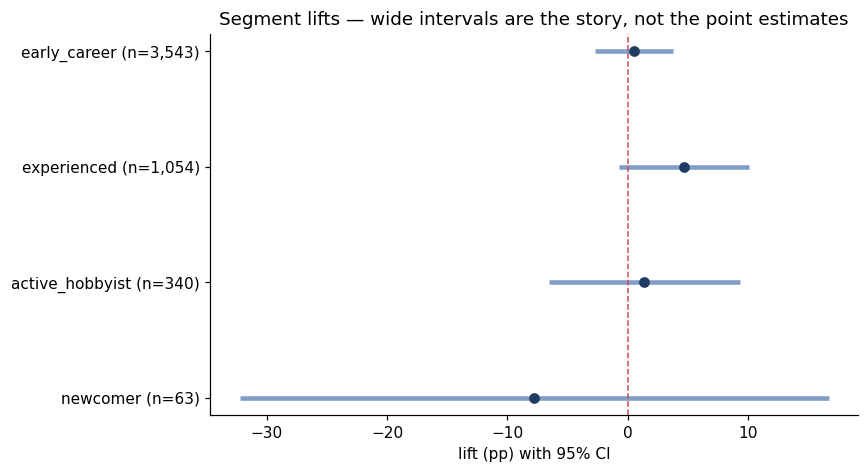

In [5]:
if "archetype" in cohort.columns:
    seg = segment_readout(cohort, alpha=ALPHA).round(3)
    print(seg.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 0.8 * len(seg) + 1.2))
    ys = np.arange(len(seg))[::-1]
    ax.hlines(ys, seg["ci_low_pp"], seg["ci_high_pp"], color="#4C72B0", lw=3, alpha=0.7)
    ax.plot(seg["lift_pp"], ys, "o", color="#1f3b63")
    ax.axvline(0, color="#C44E52", ls="--", lw=1)
    ax.set_yticks(ys, [f"{s} (n={n:,})" for s, n in zip(seg["segment"], seg["n"])])
    ax.set_xlabel("lift (pp) with 95% CI")
    ax.set_title("Segment lifts — wide intervals are the story, not the point estimates")
    plt.tight_layout()
    plt.show()
else:
    print("No archetype column")


### Why the warning label is important

After testing 4 segments, there's about a 19% chance one of them looks significant by luck alone, as demonstrated in the N=500 run.
experienced developers showed a +14.2pp lift (p = 0.020, n = 223). This is 7x the real effect, in a run where the overall result wasn't significant. 
At N=5,000 the same segment came in at +4.7pp, p = 0.090.

Neither is a reason to ship, the most they're good for is picking a hypothesis to test properly next time, decided before the data comes in. 
Additionally, newcomer (n = 63, CI about 49pp wide) is noise.

## Decision and next steps

1. **Do not ship on this readout, and do not conclude "no effect".** The result is exactly    what 31% power produces when the feature works.
2. **Rerun at 9,245/arm** (notebook 02) — about 28 days at current signup traffic.
3. **Invest in the covariate.** Raising corr(score, outcome) from 0.21 toward 0.5 cuts the    required sample meaningfully; it's the cheapest power in the building.
4. If experienced-developer targeting matters to the product, pre-register that    subgroup hypothesis for the rerun rather than promoting today's exploratory cut.
